In [4]:
import numpy as np

# 1. 假设我们有一个简单的 3x2 矩阵 A (比如 3个用户对2件商品的评分)
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

# 2. 直接调用 numpy 的 svd 函数
U, S, VT = np.linalg.svd(A)

print("矩阵 U (左奇异矩阵):\n", U)
print("\n奇异值 S (一维数组):\n", S)
print("\n矩阵 VT (右奇异矩阵的转置):\n", VT)

矩阵 U (左奇异矩阵):
 [[-0.2298477   0.88346102  0.40824829]
 [-0.52474482  0.24078249 -0.81649658]
 [-0.81964194 -0.40189603  0.40824829]]

奇异值 S (一维数组):
 [9.52551809 0.51430058]

矩阵 VT (右奇异矩阵的转置):
 [[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]


In [5]:
# 3. 将一维的 S 转换回对角矩阵 Sigma，以匹配矩阵乘法的维度 (3x2)
Sigma = np.zeros((A.shape[0], A.shape[1])) # 先建一个 3x2 的全零矩阵
Sigma[:A.shape[1], :A.shape[1]] = np.diag(S) # 把奇异值填入对角线

print("\n构建好的对角矩阵 Sigma:\n", Sigma)

# 4. 验证核心公式：A = U * Sigma * VT (在 NumPy 中矩阵乘法用 @)
A_reconstructed = U @ Sigma @ VT

print("\n还原后的矩阵 A_new:\n", np.round(A_reconstructed))


构建好的对角矩阵 Sigma:
 [[9.52551809 0.        ]
 [0.         0.51430058]
 [0.         0.        ]]

还原后的矩阵 A_new:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]


In [6]:
# 手动创建一个 3x2 的全零矩阵
Sigma = np.zeros((3, 2))
# 把一维数组 S 里的值，填回对角线
Sigma[:2, :2] = np.diag(S)
Sigma

array([[9.52551809, 0.        ],
       [0.        , 0.51430058],
       [0.        , 0.        ]])

In [11]:
import numpy as np

# 原始矩阵 A (3x2)
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

print("--- 第一步：计算协方差矩阵 ---")
ATA = A.T @ A  # 尺寸 2x2
AAT = A @ A.T  # 尺寸 3x3

print("--- 第二步：求解特征值和特征向量 ---")
# 使用 numpy 的 eig 函数求特征值和特征向量
eigvals_V, V = np.linalg.eig(ATA)
eigvals_U, U = np.linalg.eig(AAT)

# 【隐藏大坑 1：特征值必须降序排列！】
# np.linalg.eig 返回的特征值是不保证顺序的。
# SVD 的标准定义要求奇异值必须从大到小排列，所以我们要手动排序对应的特征向量。
sort_idx_V = np.argsort(eigvals_V)[::-1]  # 获取降序排列的索引
eigvals_V = eigvals_V[sort_idx_V]
V = V[:, sort_idx_V]

sort_idx_U = np.argsort(eigvals_U)[::-1]
eigvals_U = eigvals_U[sort_idx_U]
U = U[:, sort_idx_U]

print("--- 第三步：计算奇异值 ---")
# 奇异值是非零特征值的平方根。
# 注意：受计算机浮点数精度影响，极其接近 0 的特征值可能会变成微小的负数，
# 所以为了严谨，我们用 np.maximum 把负数截断为 0。
singular_values = np.sqrt(np.maximum(eigvals_V, 0))

print("\n手动提取的 奇异值 S:\n", singular_values)
print("\n手动计算的 右奇异矩阵 V:\n", V)
print("\n手动计算的 左奇异矩阵 U:\n", U)

print("\n--- 第四步：见证奇迹与陷阱 ---")
# 我们构造对角矩阵 Sigma，然后尝试用 U @ Sigma @ V.T 还原 A
Sigma = np.zeros(A.shape)
Sigma[:2, :2] = np.diag(singular_values)

A_manual = U @ Sigma @ V.T
print("\n手动还原的矩阵 A_manual:\n", np.round(A_manual, 5))
print("\n原始矩阵 A:\n", A)

--- 第一步：计算协方差矩阵 ---
--- 第二步：求解特征值和特征向量 ---
--- 第三步：计算奇异值 ---

手动提取的 奇异值 S:
 [9.52551809 0.51430058]

手动计算的 右奇异矩阵 V:
 [[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]

手动计算的 左奇异矩阵 U:
 [[-0.2298477  -0.88346102  0.40824829]
 [-0.52474482 -0.24078249 -0.81649658]
 [-0.81964194  0.40189603  0.40824829]]

--- 第四步：见证奇迹与陷阱 ---

手动还原的矩阵 A_manual:
 [[1.71326 1.43692]
 [3.19439 3.84654]
 [4.67553 6.25615]]

原始矩阵 A:
 [[1 2]
 [3 4]
 [5 6]]


In [ ]:
import numpy as np

# 原始矩阵 A (3x2)
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

print("--- 第一步：只计算尺寸更小的 A^T A ---")
ATA = A.T @ A  # 尺寸 2x2
eigvals_V, V = np.linalg.eig(ATA)

# 按照特征值降序排序
sort_idx = np.argsort(eigvals_V)[::-1]
eigvals_V = eigvals_V[sort_idx]
V = V[:, sort_idx]

# 计算奇异值 (开根号)
singular_values = np.sqrt(np.maximum(eigvals_V, 0))
print("奇异值 S:", singular_values)

print("\n--- 第二步：【核心修复】用公式强制推导 U ---")
# 我们不需要再去求庞大的 A A^T 的特征值了！
# 直接通过公式 U = A * V / Sigma 逐列计算，锁定符号！ (按列计算)  对每个非零奇异值，按公式 u_i = (A @ v_i) / sigma_i 构造左奇异向量
U_fixed = np.zeros((3, 2)) # 因为只有两个非零奇异值，U 的有效列数是 2
for i in range(len(singular_values)):
    # 核心公式落地：第 i 列的 u = (A 乘以 第 i 列的 v) / 第 i 个奇异值
    U_fixed[:, i] = (A @ V[:, i]) / singular_values[i]

print("被锁定符号的 U_fixed:\n", U_fixed)

print("\n--- 第三步：见证真正的奇迹 ---")
# 此时 U_fixed 是 3x2，Sigma 是 2x2，V.T 是 2x2
Sigma = np.diag(singular_values)
A_perfect = U_fixed @ Sigma @ V.T

print("\n完美还原的矩阵 A_perfect:\n", np.round(A_perfect, 5))
print("\n原始矩阵 A:\n", A)

--- 第一步：只计算尺寸更小的 A^T A ---
奇异值 S: [9.52551809 0.51430058]

--- 第二步：【核心修复】用公式强制推导 U ---
被锁定符号的 U_fixed:
 [[-0.2298477   0.88346102]
 [-0.52474482  0.24078249]
 [-0.81964194 -0.40189603]]

--- 第三步：见证真正的奇迹 ---

完美还原的矩阵 A_perfect:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]

原始矩阵 A:
 [[1 2]
 [3 4]
 [5 6]]


The size of the coloured image is (1440, 1440, 3)
The size of the white and black  image is (1440, 1440)


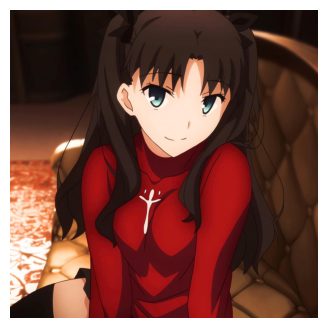

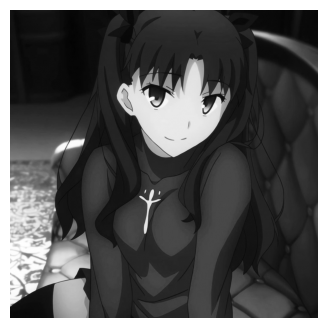

In [ ]:
#Import the needed libraries 
import matplotlib.pyplot as plt 
import numpy as np 
import os 
from matplotlib.image import imread
plt.rcParams['figure.figsize']=[16,18]

#Import the photo into python
A= imread(r"svd_assets/origin.png")
X=np.mean(A,-1) ; #Convert the RGB image to grayscale 
print(f"The size of the coloured image is {A.shape}")
print(f"The size of the white and black  image is {X.shape}")

#Plot the original coloured image
plt.figure(figsize=(4, 4))
plt.imshow(A)
plt.axis('off')
plt.show()

#Plot the white and black image version
plt.figure(figsize=(4, 4))
plt.imshow(X,cmap='gray')
plt.axis('off')
plt.show()

In [2]:
U,S,VT =np.linalg.svd(X,full_matrices=False) #Full_matrices=False means that we want the Economy Singular Value Decomposition
num_singular_values = len(S)  # This gives r = min(m, n)
print(f"First singular Value is {S[1]} and last singular value is {S[-1]}")
print(f"The number of singular values is {num_singular_values}")

First singular Value is 51445.14585184358 and last singular value is 0.007404764263590572
The number of singular values is 1440


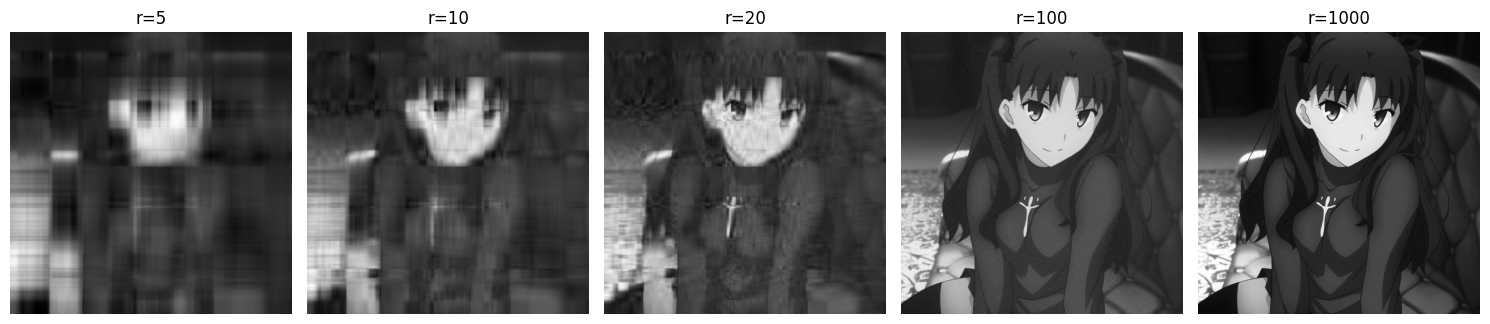

In [3]:
S = np.diag(S) 
ranks = (5, 10, 20, 100, 1000)

# Create a figure with 1 row and len(ranks) columns
fig, axes = plt.subplots(1, len(ranks), figsize=(15, 5))

for i, r in enumerate(ranks):
    # Construct approximate image
    Xapprox = U[:,:r] @ S[0:r,:r] @ VT[:r,:]
    
    # Plot in the i-th subplot
    axes[i].imshow(Xapprox, cmap='gray')
    axes[i].set_title('r=' + str(r))
    axes[i].axis('off')

plt.tight_layout()
plt.show()